In [ ]:
# IQR

In [ ]:
import pandas as pd

df = pd.read_csv("college_student_placement_dataset.csv")

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


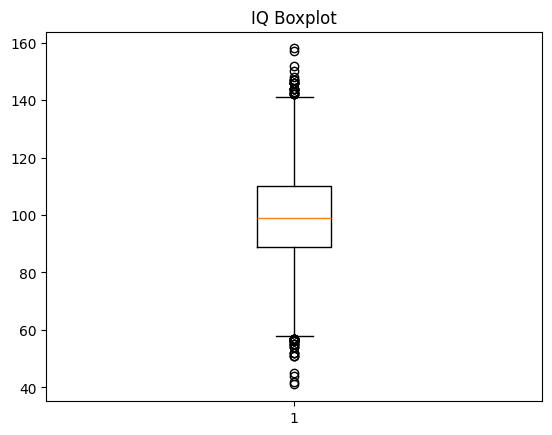

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["IQ"])
plt.title("IQ Boxplot")
plt.show()

In [ ]:
Q1 = df["IQ"].quantile(0.25)
Q3 = df["IQ"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 57.5
Upper Limit: 141.5


In [ ]:
# capping
capped_df = df.copy()

capped_df["IQ"] = capped_df["IQ"].clip(
    lower=lower_limit,
    upper=upper_limit
)

In [ ]:
df["IQ"].describe()

,IQ
count,10000.000000
mean,99.471800
std,15.053101
min,41.000000
25%,89.000000
50%,99.000000
75%,110.000000
max,158.000000


In [ ]:
capped_df["IQ"].describe()

,IQ
count,10000.000000
mean,99.471950
std,14.973821
min,57.500000
25%,89.000000
50%,99.000000
75%,110.000000
max,141.500000


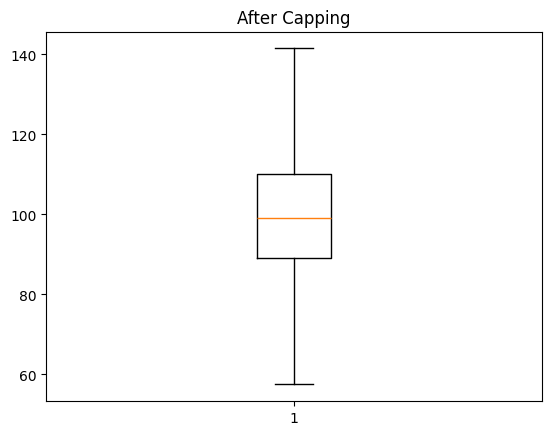

In [ ]:
plt.boxplot(capped_df["IQ"])
plt.title("After Capping")
plt.show()

In [ ]:
# triming
print(df.shape)
trimmed_df = df[
    (df["IQ"] >= lower_limit) &
    (df["IQ"] <= upper_limit)
]
print(trimmed_df.shape)

(10000, 10)
(9939, 10)


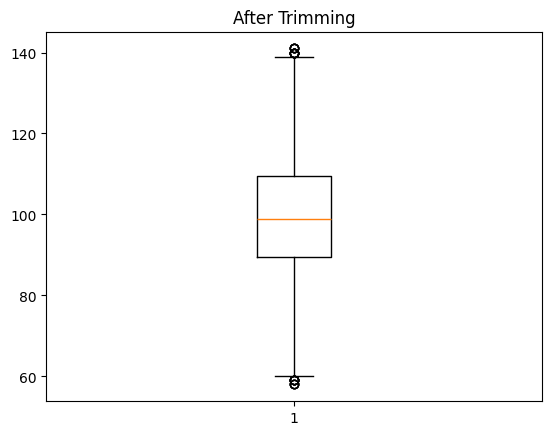

In [ ]:
plt.boxplot(trimmed_df["IQ"])
plt.title("After Trimming")
plt.show()

In [ ]:
# Z-Score


    IQ   z_score
0  107  0.500135
1   97 -0.164214
2  109  0.633004
3  122  1.496657
4   96 -0.230648
Original Shape : (10000, 11)
Trimmed Shape : (9972, 11)
Lower Limit : 54.3124955421371
Upper Limit : 144.6311044578629


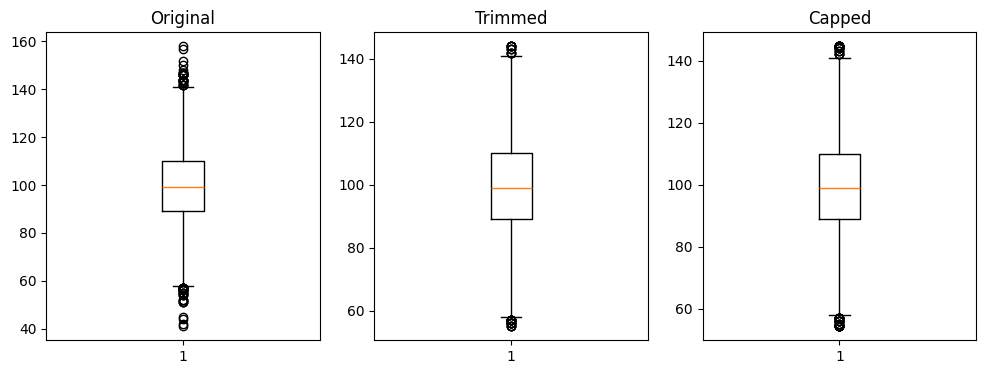

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Load dataset
df = pd.read_csv("college_student_placement_dataset.csv")

# -----------------------------
# Step 1: Calculate Z-Score
# -----------------------------
df["z_score"] = zscore(df["IQ"])

print(df[["IQ", "z_score"]].head())

# -----------------------------
# Step 2: Trimming
# Remove rows with |Z| > 3
# -----------------------------
trimmed_df = df[abs(df["z_score"]) <= 3]

print("Original Shape :", df.shape)
print("Trimmed Shape :", trimmed_df.shape)

# -----------------------------
# Step 3: Capping
# -----------------------------
mean = df["IQ"].mean()
std = df["IQ"].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

capped_df = df.copy()

capped_df["IQ"] = capped_df["IQ"].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

# -----------------------------
# Step 4: Compare Boxplots
# -----------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(df["IQ"])
plt.title("Original")

plt.subplot(1,3,2)
plt.boxplot(trimmed_df["IQ"])
plt.title("Trimmed")

plt.subplot(1,3,3)
plt.boxplot(capped_df["IQ"])
plt.title("Capped")

plt.show()

In [ ]:
# percentile


Lower Limit : 75.0
Upper Limit : 124.0
Original Shape : (10000, 10)
Trimmed Shape : (9032, 10)


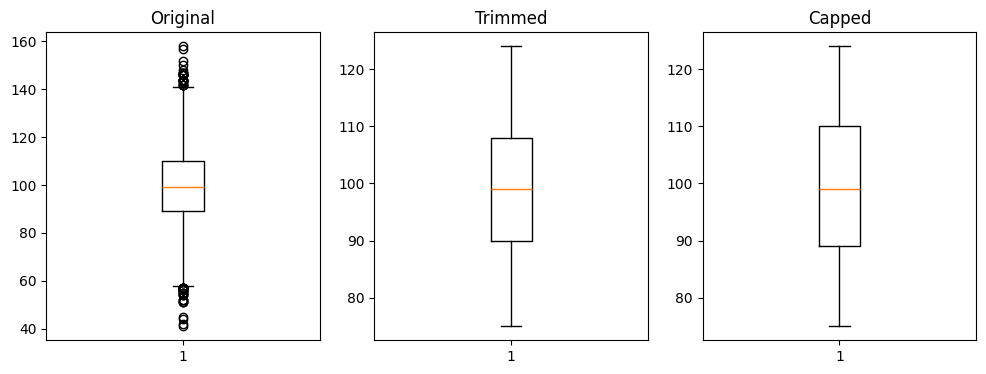

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("college_student_placement_dataset.csv")

# --------------------------------
# Step 1: Find Percentile Limits
# --------------------------------
lower_limit = np.percentile(df["IQ"], 5)
upper_limit = np.percentile(df["IQ"], 95)

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

# --------------------------------
# Step 2: Trimming
# --------------------------------
trimmed_df = df[
    (df["IQ"] >= lower_limit) &
    (df["IQ"] <= upper_limit)
]

print("Original Shape :", df.shape)
print("Trimmed Shape :", trimmed_df.shape)

# --------------------------------
# Step 3: Capping
# --------------------------------
capped_df = df.copy()

capped_df["IQ"] = capped_df["IQ"].clip(
    lower=lower_limit,
    upper=upper_limit
)

# --------------------------------
# Step 4: Compare
# --------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(df["IQ"])
plt.title("Original")

plt.subplot(1,3,2)
plt.boxplot(trimmed_df["IQ"])
plt.title("Trimmed")

plt.subplot(1,3,3)
plt.boxplot(capped_df["IQ"])
plt.title("Capped")

plt.show()